# Volume Metric Tests

## Setup

### Imports

In [1]:
from math import isnan
from math import nan
from pprint import pprint

from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from structures import *
from composite_structure import *
from relations import *

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [2]:
%matplotlib inline

### Utility Functions

## Volume Metric Algorithms


Currently, volumes are calculated by edges in the contour graph. 
See the `volume` method in the `ContourMatch` class.

The `calculate_physical_volume()` method in the `StructureShape` class adds all 
edge volumes for the structure and subtracts all hole volumes.


### Structure creation workflow
1. build slice_data: List[ContourPoints]
  - ContourPoints: Dict[str, Any]
    - 'ROI': int
    - 'Slice': float
    - 'Points': List[Tuple[float, float, float]]
2. build contour_table from slice_data
  - contour_table: DataFrame  Columns:
    - 'ROI', 'Slice', 'Points', 'Polygon': shapely.Polygon, 'Area': float
    - sorted by ['ROI', 'Slice', 'Area'], ascending=[True, True, False]
3. for each ROI create a StructureShape
  - StructureShape(roi=roi, name=structure_name)
4. use StructureShape.add_contour_graph() to add contours from the contour_table

### Create a new function `build_contour_table_from_polygons`

- A function that creates a contour_table from a list of MultiPolygons.
- Takes a list of shapely.Multipolygon, and an ROI number as input.
1. Raise an error if the MultiPolygons are not 3D (do not have a Z coordinate).
2. Create an empty contours list.
3. For each MultiPolygon:
    1. Extract the Z coordinate from each MultiPolygons to use as the 'Slice'.
    2. For each polygon in the MultiPolygon:
        1. Extract the exterior coordinates of the polygon.
        2. Create a new polygon from these coordinates
        3. Calculate the area of the new polygon.
        4. Add the 'ROI', 'Slice', 'Points', 'Polygon', and 'Area' to the contours list.
        5. For each hole in the polygon:
            1. Extract the coordinates of the hole.
            2. Create a new polygon from these coordinates.
            3. Calculate the area of the new polygon.
            4. Add the 'ROI', 'Slice', 'Points', 'Polygon', and 'Area' to the contours list.
4. Convert the list to a pandas DataFrame.
5. Sort the DataFrame by=['ROI', 'Slice', 'Area'], ascending=[True, True, False]
6. Generate the slice sequence for the contours
7. return the contour_table and slice_sequence

### Volume Metric Types
<table>
<tr><th>Structures</th><th>Union</th><th>Intersection</th><th>Difference</th></tr>
<tr>
<td><img src="../../Images/2D Relations/2 volumes.png" alt="Equals"></td>
<td><img src="../../Images/2D Relations/Volume Union.png" alt="Equals"></td>
<td><img src="../../Images/2D Relations/Volume intersection.png" alt="Equals"></td>
<td><img src="../../Images/2D Relations/Volume Difference.png" alt="Equals"></td>
</tr></table>


### Create a CompositeStructure class

Add a class `CompositeStructure` that inherits from `StructureShape`. 
- `CompositeStructure` includes an `expression` attribute of type string.
- expression references the original structures. 

- Add a method `structure_boolean`  
- `structure_boolean` takes two or more `StructureShape` objects and an expression of type str
- `structure_boolean` returns a new `CompositeStructure` object.
- *expression* has the format A \<operator> B, 
   where \<operator> can be UNION (or |), INTERSECTION (or &), or DIFFERENCE (or -).
- boolean generates one of the Union, Intersection or Difference of two structures.

- ROI becomes a unique ROI negative number 
   (negative values indicate a construct rather than original structure).
- The `structure_name` reflects the starting structures and the operation.
- The `structure_name` is derived from expression with [ROI] replacing A or B.
- If the A or B StructureShape is a `CompositeStructure`, its name should be used 
   in place of A or B in the new expression.

1. Create an empty list of polygons
2. Use StructureShape.contour_lookup to group contours by their SliceIndex.
3. For each Slice Index:
   1. Drop all Boundary or Interpolated contours.
   2. Merge all of the contours into a MultiPolygon
   3. Do the same thing for the other `StructureShape` object(s).
   4. If either of the StructureShapes has no contours for the current SliceIndex, 
      Use an empty MultiPolygon.
   5. Apply the structure_boolean operation specified in the expression to the MultiPolygons.
   6. If the resulting MultiPolygon is empty, skip this SliceIndex.
   7. Force the resulting MultiPolygon to be valid and 3D, with SliceIndex as the Z-coordinate.
   8. Append the resulting MultiPolygon to the list of polygons.
4. Create a new `CompositeStructure` with the appropriate name and ROI.
5. Get `slice_sequence` from the structure set.
6. Create a new `contour_table` from the list of polygons.
7. Build the `CompositeStructure` with the resulting `contour_table`, 
   the `slice_sequence` from the structure set, the new ROI the new `structure_name`.
8. finalize the `CompositeStructure`



- Volume Metrics are only Meaningful for "Shared" Relationships (Equal, Contains, Partitioned, Overlaps).
- Volume Metrics can be applied to situations with > 2 structures, but are then not tied to a relationship.


### Volume Metric Values by Relationship

<table>
<tr class="l"><th>Relationship</th><th>Example</th><th>Volume Metric Values</th></tr>

<tr><td>EQUAL</td>
<td><img src="../../Images/Relationships/equals.png" alt="Equals" ></td>
<td> 
Union = Intersection = V<sub>A</sub> = V<sub>B</sub><br> 
Difference = 0
</td></tr>

<tr><td>CONTAINS</td>
<td><img src="../../Images/Relationships/contains simple.png" alt="Contains"></td>
<td>
Union = V<sub>A</sub><br>
Intersection = V<sub>B</sub><br>
Difference =V<sub>A</sub> - V<sub>B</sub>
</td></tr>
<tr><td>PARTITIONED</td>
<td><img src="../../Images/Relationships/partitions simple.png" alt="Partition"></td>
<td>
Union = V<sub>A</sub><br>
Intersection = V<sub>B</sub><br>
Difference =V<sub>A</sub> - V<sub>B</sub></td>
</td></tr>

<tr><td>OVERLAPS</td>
<td><img src="../../Images/Relationships/overlaps simple.png" alt="Overlaps"></td>
<td>
V<sub>A</sub> + V<sub>B</sub> > Union<br>
V<sub>A</sub> > Intersection<br>
V<sub>B</sub> > Intersection<br>
Difference > 0</td>
</tr>

<tr><td colspan="2"  width="150px">
BORDERS, CONFINES, SURROUNDS, SHELTERS, DISJOINT
</td>

<td>
Union = V<sub>A</sub> + V<sub>B</sub><br>
Intersection = 0<br>
Difference = 0</td>
</tr></table>


### Calculation Tests for Composite Structures
1. Make Structure Set
2. Make the Composite Structure
3. Get the physical volume of the composite structure
4. Verify the volume against expected values

Test shapes to use:
- Contains test (cube in cube)
- Partitioned test (cube and half cube)
- Overlaps test (overlapping cubes)
- Disjoint test (disjoint cubes)

#### Contains Tests

In [3]:
def embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = outer_cube + inner_cube + body
    return slice_data

slice_data = embedded_boxes_example()
structures = StructureSet(slice_data, logging_enabled=False)
union_structure = structure_boolean(structures, expression='1 UNION 2')
intersection_structure = structure_boolean(structures, expression='1 INTERSECTION 2')
difference_structure = structure_boolean(structures, expression='1 DIFFERENCE 2')

# Expected vs actual volumes
structure_1_volume = structures.structures[1].structure_volumes.physical
structure_2_volume = structures.structures[2].structure_volumes.physical
expected_volumes = {'Union_1_2': structure_1_volume,
                    'intersection_1_2': structure_2_volume,
                    'difference_1_2': structure_1_volume - structure_2_volume}
print(f'Structure 1 Volume: Ideal:{4.0*4.0*4.0:5.2f}\tActual:{structure_1_volume:5.2f}')
print(f'Structure 2 Volume: Ideal:{2.0*2.0*2.0:5.2f}\tActual:{structure_2_volume:5.2f}')
for key, value in expected_volumes.items():
    print(f'Expected {key}: {value:5.2f}')
print(f'Union Structure Volume: {union_structure.structure_volumes.physical:5.2f}')
print(f'Intersection Structure Volume: {intersection_structure.structure_volumes.physical:5.2f}')
print(f'Difference Structure Volume: {difference_structure.structure_volumes.physical:5.2f}')


Structure 1 Volume: Ideal:64.00	Actual:65.00
Structure 2 Volume: Ideal: 8.00	Actual: 8.25
Expected Union_1_2: 65.00
Expected intersection_1_2:  8.25
Expected difference_1_2: 56.75
Union Structure Volume: 65.00
Intersection Structure Volume:  8.25
Difference Structure Volume: 58.35


In [4]:
def simple_embedded_sphere_example():
    slice_spacing = 0.1
    # embedded spheres
    sphere6 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing, num_points=100)
    sphere3 = make_sphere(roi_num=2, radius=3, spacing=slice_spacing, num_points=100)
    # combine the contours
    slice_data = sphere6 + sphere3
    return slice_data


slice_data = simple_embedded_sphere_example()
structures = StructureSet(slice_data, logging_enabled=False)
union_structure = structure_boolean(structures, expression='1 UNION 2')
intersection_structure = structure_boolean(structures, expression='1 INTERSECTION 2')
difference_structure = structure_boolean(structures, expression='1 DIFFERENCE 2')

# Expected vs actual volumes
structure_1_volume = structures.structures[1].structure_volumes.physical
structure_2_volume = structures.structures[2].structure_volumes.physical
expected_volumes = {'Union_1_2': structure_1_volume,
                    'intersection_1_2': structure_2_volume,
                    'difference_1_2': structure_1_volume - structure_2_volume}
print(f'Structure 1 Volume: Ideal:{4/3*3.14159*6**3:5.2f}\tActual:{structure_1_volume:5.2f}')
print(f'Structure 2 Volume: Ideal:{4/3*3.14159*3**3:5.2f}\tActual:{structure_2_volume:5.2f}')
for key, value in expected_volumes.items():
    print(f'Expected {key}: {value:5.2f}')
print(f'Union Structure Volume: {union_structure.structure_volumes.physical:5.2f}')
print(f'Intersection Structure Volume: {intersection_structure.structure_volumes.physical:5.2f}')
print(f'Difference Structure Volume: {difference_structure.structure_volumes.physical:5.2f}')


Structure 1 Volume: Ideal:904.78	Actual:904.12
Structure 2 Volume: Ideal:113.10	Actual:112.99
Expected Union_1_2: 904.12
Expected intersection_1_2: 112.99
Expected difference_1_2: 791.13
Union Structure Volume: 904.12
Intersection Structure Volume: 112.99
Difference Structure Volume: 799.56


#### Overlaps Test

In [5]:
def overlapping_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=4, offset_x=-1, offset_z=0,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=4, offset_x=1, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data

slice_data = overlapping_boxes_example()
structures = StructureSet(slice_data, logging_enabled=False)
union_structure = structure_boolean(structures, expression='1 UNION 2')
intersection_structure = structure_boolean(structures, expression='1 INTERSECTION 2')
difference_structure = structure_boolean(structures, expression='1 DIFFERENCE 2')

# Expected vs actual volumes
structure_1_volume = structures.structures[1].structure_volumes.physical
structure_2_volume = structures.structures[2].structure_volumes.physical
expected_volumes = {'Union_1_2': structure_1_volume + structure_2_volume - structure_1_volume / 2,
                    'intersection_1_2': structure_2_volume / 2,
                    'difference_1_2': structure_1_volume / 2}
print(f'Structure 1 Volume: Ideal:{4.0*4.0*4.0:5.2f}\tActual:{structure_1_volume:5.2f}')
print(f'Structure 2 Volume: Ideal:{4.0*4.0*4.0:5.2f}\tActual:{structure_2_volume:5.2f}')
for key, value in expected_volumes.items():
    print(f'Expected {key}: {value:5.2f}')
print(f'Union Structure Volume: {union_structure.structure_volumes.physical:5.2f}')
print(f'Intersection Structure Volume: {intersection_structure.structure_volumes.physical:5.2f}')
print(f'Difference Structure Volume: {difference_structure.structure_volumes.physical:5.2f}')


Structure 1 Volume: Ideal:64.00	Actual:65.00
Structure 2 Volume: Ideal:64.00	Actual:65.00
Expected Union_1_2: 97.50
Expected intersection_1_2: 32.50
Expected difference_1_2: 32.50
Union Structure Volume: 97.50
Intersection Structure Volume: 32.50
Difference Structure Volume: 32.50


#### Partitions Test

In [6]:
def partitioning_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube = make_box(roi_num=2, width=4, length=4, height=2, offset_x=0, offset_z=1,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = outer_cube + inner_cube + body
    return slice_data

slice_data = partitioning_boxes_example()
structures = StructureSet(slice_data, logging_enabled=False)
union_structure = structure_boolean(structures, expression='1 UNION 2')
intersection_structure = structure_boolean(structures, expression='1 INTERSECTION 2')
difference_structure = structure_boolean(structures, expression='1 DIFFERENCE 2')

# Expected vs actual volumes
structure_1_volume = structures.structures[1].structure_volumes.physical
structure_2_volume = structures.structures[2].structure_volumes.physical
expected_volumes = {'Union_1_2': structure_1_volume,
                    'intersection_1_2': structure_2_volume,
                    'difference_1_2': structure_1_volume - structure_2_volume}
print(f'Structure 1 Volume: Ideal:{4.0*4.0*4.0:5.2f}\tActual:{structure_1_volume:5.2f}')
print(f'Structure 2 Volume: Ideal:{4.0*4.0*2.0:5.2f}\tActual:{structure_2_volume:5.2f}')
for key, value in expected_volumes.items():
    print(f'Expected {key}: {value:5.2f}')
print(f'Union Structure Volume: {union_structure.structure_volumes.physical:5.2f}')
print(f'Intersection Structure Volume: {intersection_structure.structure_volumes.physical:5.2f}')
print(f'Difference Structure Volume: {difference_structure.structure_volumes.physical:5.2f}')


Structure 1 Volume: Ideal:64.00	Actual:65.00
Structure 2 Volume: Ideal:32.00	Actual:33.00
Expected Union_1_2: 65.00
Expected intersection_1_2: 33.00
Expected difference_1_2: 32.00
Union Structure Volume: 65.00
Intersection Structure Volume: 33.00
Difference Structure Volume: 31.40


#### Disjoint Test

In [7]:
def disjoint_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=-2, offset_z=0,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=2, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data

slice_data = disjoint_boxes_example()
structures = StructureSet(slice_data, logging_enabled=False)
union_structure = structure_boolean(structures, expression='1 UNION 2')
intersection_structure = structure_boolean(structures, expression='1 INTERSECTION 2')
difference_structure = structure_boolean(structures, expression='1 DIFFERENCE 2')

# Expected vs actual volumes
structure_1_volume = structures.structures[1].structure_volumes.physical
structure_2_volume = structures.structures[2].structure_volumes.physical
expected_volumes = {'Union_1_2': structure_1_volume + structure_2_volume,
                    'intersection_1_2': 0.0,
                    'difference_1_2': structure_1_volume}
print(f'Structure 1 Volume: Ideal:{2.0*2.0*2.0:5.2f}\tActual:{structure_1_volume:5.2f}')
print(f'Structure 2 Volume: Ideal:{2.0*2.0*2.0:5.2f}\tActual:{structure_2_volume:5.2f}')
for key, value in expected_volumes.items():
    print(f'Expected {key}: {value:5.2f}')
print(f'Union Structure Volume: {union_structure.structure_volumes.physical:5.2f}')
print(f'Intersection Structure Volume: {intersection_structure.structure_volumes.physical:5.2f}')
print(f'Difference Structure Volume: {difference_structure.structure_volumes.physical:5.2f}')


Structure 1 Volume: Ideal: 8.00	Actual: 8.25
Structure 2 Volume: Ideal: 8.00	Actual: 8.25
Expected Union_1_2: 16.50
Expected intersection_1_2:  0.00
Expected difference_1_2:  8.25
Union Structure Volume: 16.50
Intersection Structure Volume:  0.00
Difference Structure Volume:  8.25


## Per Region Volumes
Implement a per-region volume method by grouping graph edges by 
`contour.region_index` and applying per region, the 
same add/subtract-hole logic used for the overall volume calculation. 

- Include an argument in the method to specify whether to calculate the 
Physical, Exterior or Hull volumes.  The default should be 'Physical'
- This method is not to be called with the finalize method like the overall 
volume calculation.  It will only be called as needed

- The output of this method should be a dictionary mapping each region index to its calculated volume.



### Tests of Per-Region Volumes

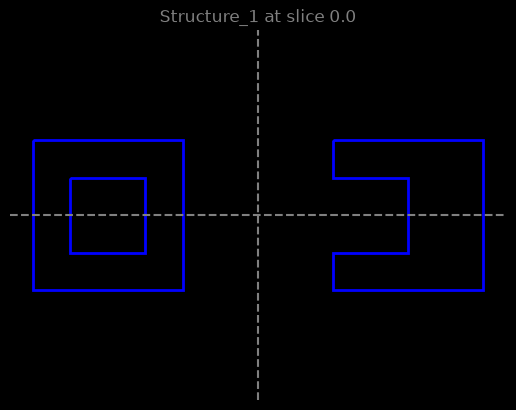

Physical volumes: {'1A': 58.35, '1B': 58.35}
Exterior volumes: {'1A': 66.6, '1B': 58.35}
Hull volumes: {'1A': 66.6, '1B': 66.6}


In [9]:
def two_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=4, offset_x=-4, offset_z=0,
                         spacing=slice_spacing)
    left_cube_centre_hole = make_box(roi_num=1, width=2, offset_x=-4,
                                     offset_z=0, spacing=slice_spacing)
    right_cube = make_box(roi_num=1, width=4, offset_x=4, offset_z=0,
                          spacing=slice_spacing)
    right_cube_open_hole = make_box(roi_num=1, width=2, offset_x=3,
                                    offset_y=0, spacing=slice_spacing)

    # Combine the contours
    slice_data = left_cube + left_cube_centre_hole + right_cube + right_cube_open_hole + body
    return slice_data

slice_data = two_boxes_example()
structures = StructureSet(slice_data, logging_enabled=False, tolerance=0.01)
structure_1 = structures.structures[1]
plot_roi_slice(structures, 0.0, [1], add_axis= True, show_legend=False)
physical_volume = structure_1.calculate_region_volumes(
    volume_type="Physical",
    tolerance=structures.tolerance)
exterior_volume = structure_1.calculate_region_volumes(
    volume_type="Exterior",
    tolerance=structures.tolerance)
hull_volume = structure_1.calculate_region_volumes(
    volume_type="Hull",
    tolerance=structures.tolerance)
print(f'Physical volumes: {physical_volume}')
print(f'Exterior volumes: {exterior_volume}')
print(f'Hull volumes: {hull_volume}')
a = structure_1.contour_lookup
#print(a[a.loc[:, 'SliceIndex'] == 0][['RegionIndex', 'HoleType','Label']])

## Volume Ratios
### Possible Ratios
<table>
<tr><th>Ratio</th><th>Range</th><th><i>CONTAINS</i> and <i>PARTITIONED</i></th></tr>
<tr><td>Intersection / Union</td><td>0 to 1</td><td></td></tr>
<tr><td>Difference / Union</td><td>0 to 1</td><td>1 - Intersection / Union</td></tr>
<tr><td>Difference / Intersection</td><td>0 to infinity</td><td>0</td></tr>
<tr><td>V<sub>A</sub> / Union</td><td>0 to 1</td><td>1</td></tr>
<tr><td>Intersection / V<sub>A</sub></td><td>0 to 1</td><td>Intersection / Union</td></tr>
<tr><td>V<sub>B</sub> / V<sub>A</sub></td><td>0 to 1</td><td>Intersection / Union</td></tr>
<tr><td>Difference / V<sub>A</sub></td><td>0 to 1</td><td>0</td></tr>
</table>


# Done To Here

## Data Storage Updates 
Metrics Storage Data:
- Volume Ratio metric 
    - Final Volume Ratio value across all region pairs and reference slices.
    - Values for each slice
    > - Are ratio values per region useful?  -- YES
    > - Summary values for each region pair??  -- Yes
    > - Summary values for each reference slice.  -- No


- Only implement these two to begin with.
  Others can be implemented later by editing Json file with Ratio definitions.
  - Intersection / Union
  - Difference / Union (= 1 - Intersection / Union for *CONTAINS* and *PARTITIONED*)



#### Create Two volume_ratio metrics
  - Overlapping (Intersection / Union)
  - Non-Overlapping (Difference / Union)

- Each is called and calculated seperately

Process:
1. Verify that there is a "Shared" Relationship between the structures. 
    (Equal, Contains, Partitioned, Overlaps).
2. If the relationship is not "Shared", raise a warning and return an empty 
     Volume Ratio metric.
3. If the relationship is Equal, a CompositeStructure is not nessesary.
     Return the Volume Ratio metric with following values 
     (including Per-region values):
         - Overlapping: 1.0
         - Non-Overlapping: 0.0
4. Calculate the nessesary CompositeStructures
    - Intersection and  Union or 
    - Difference and Union
5. Obtain the per-region "Physical" volumes of the CompositeStructures
6. Calculate the requested ratio Across all non-hole regions in the two structures 
   (All ratios contain one region in each stucture per calculation)
7. Calculate the overall ratio from  the total volumes of the CompositeStructures
    (Do not use region aggregation because of rounding and boundary issues)
8. Build the final Metric
    - Overall Volume Ratio.
    - Ratio values per region pair